# 加载需要的R包

In [48]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()

In [49]:
orfs_path <- "../../results/orfs_merged_final.tsv"
fread_c(orfs_path) -> orfs
# 过滤掉污染
orfs %>% filter(!grepl("Cont",ORF_id)) -> orfs
head(orfs,1)
nrow(orfs)
colnames(orfs)

,ORF_id,ORF_type,Start_codon,Isoform_id,Chr,Strand,ORF_seq,ORF_length,Geneid,Isoform_structural_category,⋯,Psites_codon_coverage,FL,FL_TPM,N,C,A,Gene_type,Unique_peptide_n,Unique_peptide_n_msfragger_closed,mean_relative_iBAQ
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,canonical,ATG,PB.10027.4,chr12,-,MATLKEKLIAPVAEEEATVPNNKITVVGVGQVGMACAISILGKSLADELALVDVLEDKLKGEMMDLQHGSLFLQTPKIVADKDYSVTANSKIVVVTAGVRQQEGESRLNLVQRNVNVFKFIIPQIVKYSPDCIIIVVSNPVDILTYVTWKLSGLPKHRVIGSGCNLDSARFRYLMAEKLGIHPSSCHGWILGEHGDSSVAVWSGVNVAGVSLQELNPEMGTDNDSENWKEVHKMVVESAYEVIKLKGYTNWAIGLSVADLIESMLKNLSRIHPVSTMVKGMYGIENEVFLSLPCILNARGLTSVINQKLKDDEVAQLKKSADTLWDIQKDLKDL,334,LDHB,full-splice_match,⋯,315.506,4163,568.9832,0.3698762,0.07221995,0.2210481,protein_coding,52,36,0.001852398


[1] 27613

[1] "ORF_id"                            "ORF_type"                         
 [3] "Start_codon"                       "Isoform_id"                       
 [5] "Chr"                               "Strand"                           
 [7] "ORF_seq"                           "ORF_length"                       
 [9] "Geneid"                            "Isoform_structural_category"      
[11] "Isoform_subcategory"               "Is_uniprot"                       
[13] "Is_canonical"                      "Run_occurrence"                   
[15] "RPF_reads"                         "Psites_number"                    
[17] "RPF_RPKM"                          "Psites_RPKM"                      
[19] "RPF_codon_coverage"                "Psites_codon_coverage"            
[21] "FL"                                "FL_TPM"                           
[23] "N"                                 "C"                                
[25] "A"                                 "Gene_type"                        
[27] "Unique_peptide_n"                  "Unique_peptide_n_msfragger_closed"
[29] "mean_relative_iBAQ"

In [7]:
# 导出check de novo状态
nrow(orfs)
orfs %>% filter(Is_canonical=="FALSE") -> tmp
fwrite_c(select(tmp,ORF_id),"../../results/noncano.id.lst",col.names = F)
fwrite_c(select(orfs,ORF_id),"../../results/ribo_ms.id.lst",col.names = F)

[1] 27613

In [16]:
table(orfs$Is_canonical)


FALSE  TRUE 
17681  9932 

In [17]:
n_distinct(orfs$Geneid)
n_distinct(orfs$Isoform_id)

[1] 13694

[1] 22132

# ORF类型统计

In [52]:
output_path <- "../../figures/noncano"
head(orfs$Is_canonical)

[1] TRUE TRUE TRUE TRUE TRUE TRUE

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


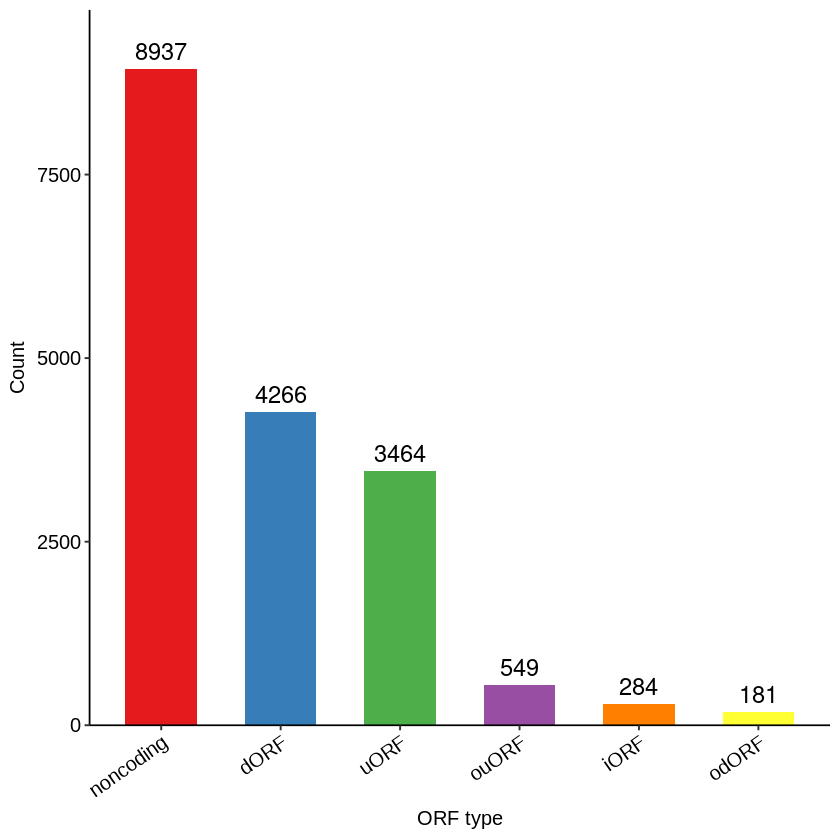

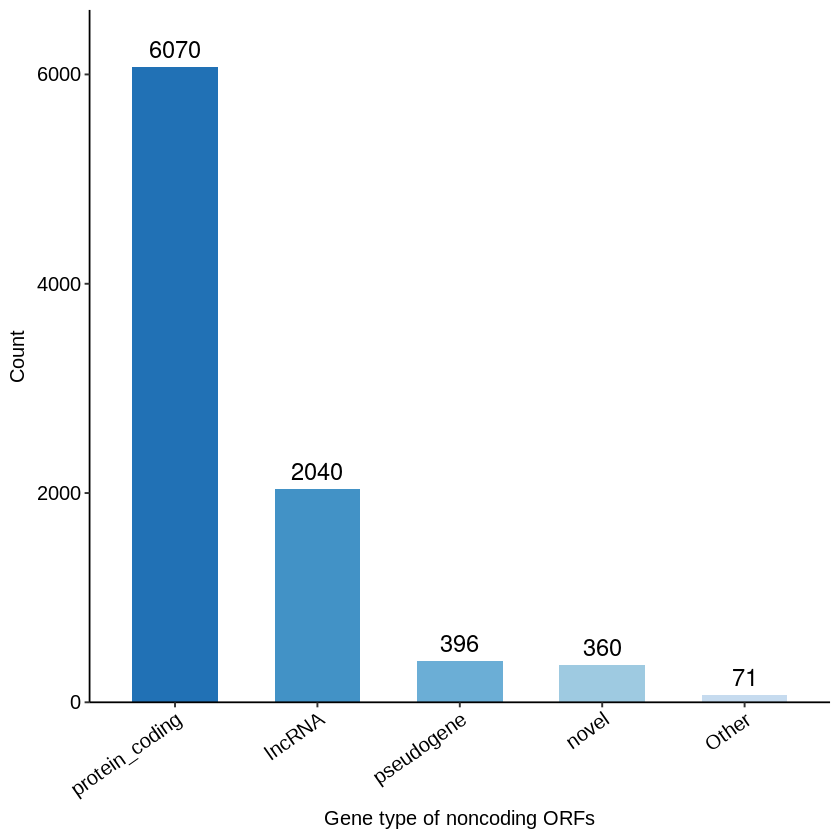

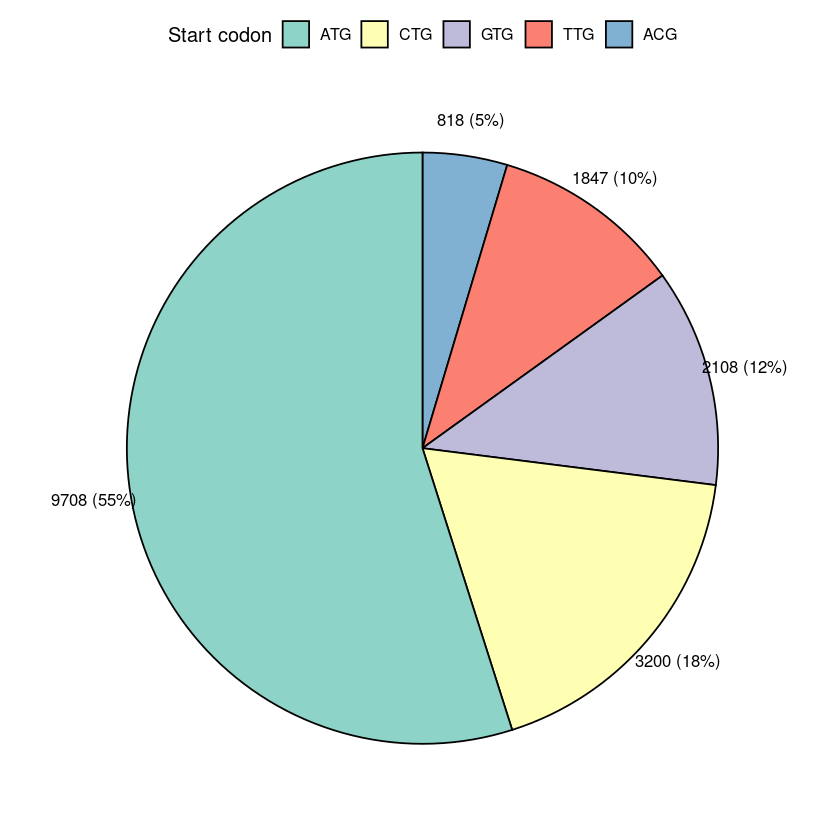

In [53]:
orfs  %>% filter(Is_canonical=="FALSE")-> df
## 不同的ORF类型
df %>% count(ORF_type) %>% arrange(desc(n)) -> df_type_n
df_type_n$ORF_type <- factor(df_type_n$ORF_type,levels = df_type_n$ORF_type)
df_type_n %>%  bar_plot_basic(., "ORF_type","n",fil_col = "ORF_type",label = T)+
guides(fill="none")+labs(x="ORF type",y="Count")+
theme(axis.text.x = element_text(angle=35,vjust = 1,hjust = 1))-> p1
p1
ggsave(p1,filename = o("ORF_type.pdf"),height = 5,width = 5)

filter(df, ORF_type == "noncoding") %>% 
  mutate(Gene_type_1 = case_when(
    grepl("pseudogene", Gene_type) ~ "pseudogene",
    Gene_type %in% c("Mt_rRNA", "TEC", "artifact", "misc_RNA") ~ "Other",
    TRUE ~ Gene_type
  )) %>% 
  count(Gene_type_1) %>% 
arrange(desc(n)) %>% 
mutate(Gene_type_1=factor(Gene_type_1,levels=Gene_type_1)) %>% 
bar_plot_basic(., "Gene_type_1","n",fil_col = "Gene_type_1",label = T)+
scale_fill_manual(values = rev(brewer.pal(name = "Blues",n=9)[3:7]))+
labs(x="Gene type of noncoding ORFs",y="Count")+
theme_3(rotate = T)+
guides(fill="none")->p2
p2
ggsave(p2,filename = o("noncodoing.orf.gene.type.pdf"),height = 5,width = 5)

## start codon
df %>% count(Start_codon) %>% arrange(desc(n)) -> df_1
df$Start_codon <- factor(df$Start_codon,levels = df_1$Start_codon)
pie_plot(df,"Start_codon") + labs(fill="Start codon") -> p3
p3
ggsave(p3,filename = o("scodon_type.pdf"),height = 5,width = 5)

# ## ms evidence
# df %>% mutate(Unique_peptide_n_1=
#                 case_when(Unique_peptide_n > 2 ~ ">2",
#                           TRUE ~ as.character(Unique_peptide_n))) -> df
# df$Unique_peptide_n_1 <- factor(df$Unique_peptide_n_1,levels = c("1","2",">2"))
# pie_plot(df,"Unique_peptide_n_1")+
#   guides(fill = guide_legend(title = "Unique peptide number")) -> p
# p
# ggsave(p,filename = o("unique_peptide_n.pdf"),height = 5,width = 5)

In [60]:
df_type_n %>% mutate(Pro=n/sum(n))

ORF_type,n,Pro
<fct>,<int>,<dbl>
noncoding,8937,0.50545784
dORF,4266,0.24127595
uORF,3464,0.19591652
ouORF,549,0.03105028
iORF,284,0.01606244
odORF,181,0.01023698


In [59]:
filter(df, ORF_type == "noncoding") %>% 
  mutate(Gene_type_1 = case_when(
    grepl("pseudogene", Gene_type) ~ "pseudogene",
    Gene_type %in% c("Mt_rRNA", "TEC", "artifact", "misc_RNA") ~ "Other",
    TRUE ~ Gene_type
  )) %>% 
  count(Gene_type_1) -> tmp
tmp %>% mutate(Pro=n/sum(n))

Gene_type_1,n,Pro
<chr>,<int>,<dbl>
Other,71,0.00794450
lncRNA,2040,0.22826452
novel,360,0.04028197
protein_coding,6070,0.67919884
pseudogene,396,0.04431017


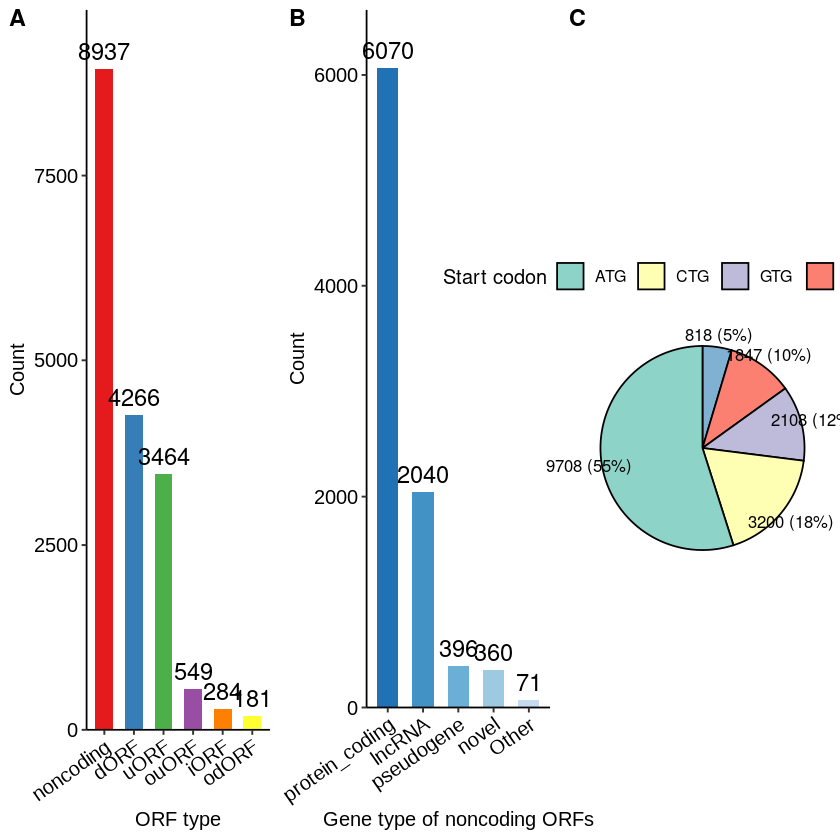

In [54]:
combined_plot1 <- plot_grid(p1, p2, p3, 
                            ncol = 3, nrow = 1, labels = "AUTO")
combined_plot1
ggsave(filename = o("combined_plot.pdf"), plot = combined_plot1, height = 4, width = 15)

In [31]:
brewer.pal(name = "Blues",n=9)[4:8]

[1] "#9ECAE1" "#6BAED6" "#4292C6" "#2171B5" "#08519C"